In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib


Loading preprocessed data...
Train set: (291299, 13)
Test set: (72825, 13)
Target distribution (train): has_diabetes
1.0    50.00%
0.0    50.00%
Name: proportion, dtype: object
Target distribution (test): has_diabetes
0.0    50.00%
1.0    50.00%
Name: proportion, dtype: object

TRAINING: XGBoost
Model saved to ..\models\xgboost_model

CONFUSION MATRIX (XGBoost):
[[25661 10752]
 [ 7615 28797]]

CLASSIFICATION REPORT (XGBoost):

              precision    recall  f1-score   support

 No Diabetes       0.77      0.70      0.74     36413
    Diabetes       0.73      0.79      0.76     36412

    accuracy                           0.75     72825
   macro avg       0.75      0.75      0.75     72825
weighted avg       0.75      0.75      0.75     72825


Accuracy Analysis for XGBoost:
   - Overall Accuracy: 74.78% (54458/72825 correct)
   - False Negatives (Missed Diabetics): 7615 cases
   - False Positives (False Alarms): 10752 cases


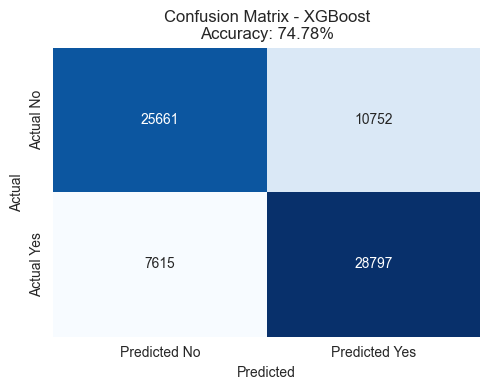


TRAINING: CatBoost
Model saved to ..\models\catboost_model

CONFUSION MATRIX (CatBoost):
[[25755 10658]
 [ 7605 28807]]

CLASSIFICATION REPORT (CatBoost):

              precision    recall  f1-score   support

 No Diabetes       0.77      0.71      0.74     36413
    Diabetes       0.73      0.79      0.76     36412

    accuracy                           0.75     72825
   macro avg       0.75      0.75      0.75     72825
weighted avg       0.75      0.75      0.75     72825


Accuracy Analysis for CatBoost:
   - Overall Accuracy: 74.92% (54562/72825 correct)
   - False Negatives (Missed Diabetics): 7605 cases
   - False Positives (False Alarms): 10658 cases


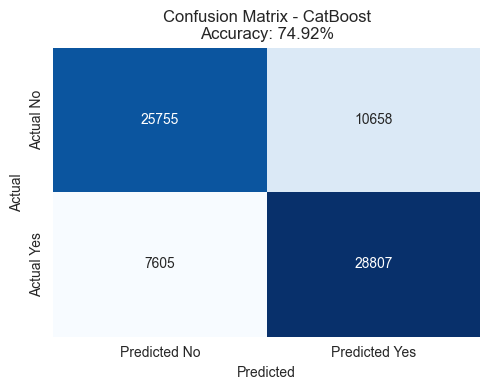


TRAINING: Random Forest
Model saved to ..\models\random_forest_model

CONFUSION MATRIX (Random Forest):
[[24731 11682]
 [10183 26229]]

CLASSIFICATION REPORT (Random Forest):

              precision    recall  f1-score   support

 No Diabetes       0.71      0.68      0.69     36413
    Diabetes       0.69      0.72      0.71     36412

    accuracy                           0.70     72825
   macro avg       0.70      0.70      0.70     72825
weighted avg       0.70      0.70      0.70     72825


Accuracy Analysis for Random Forest:
   - Overall Accuracy: 69.98% (50960/72825 correct)
   - False Negatives (Missed Diabetics): 10183 cases
   - False Positives (False Alarms): 11682 cases


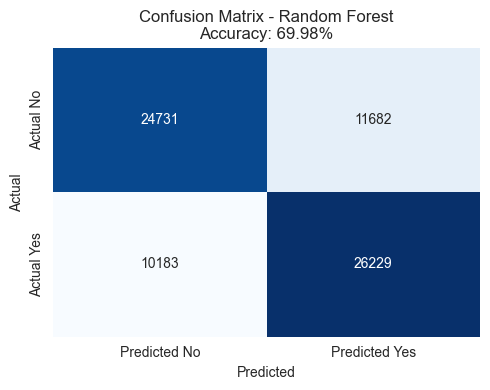


TRAINING: Extra Trees
Model saved to ..\models\extra_trees_model

CONFUSION MATRIX (Extra Trees):
[[24917 11496]
 [11344 25068]]

CLASSIFICATION REPORT (Extra Trees):

              precision    recall  f1-score   support

 No Diabetes       0.69      0.68      0.69     36413
    Diabetes       0.69      0.69      0.69     36412

    accuracy                           0.69     72825
   macro avg       0.69      0.69      0.69     72825
weighted avg       0.69      0.69      0.69     72825


Accuracy Analysis for Extra Trees:
   - Overall Accuracy: 68.64% (49985/72825 correct)
   - False Negatives (Missed Diabetics): 11344 cases
   - False Positives (False Alarms): 11496 cases


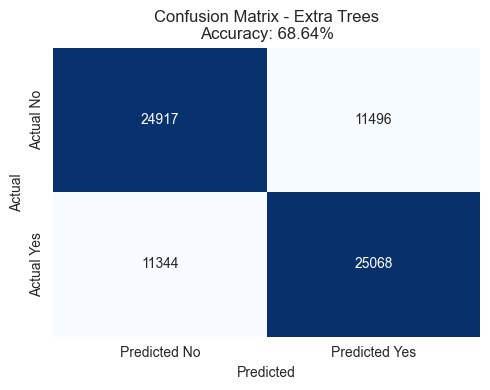


Results saved to ..\models\model_results.json


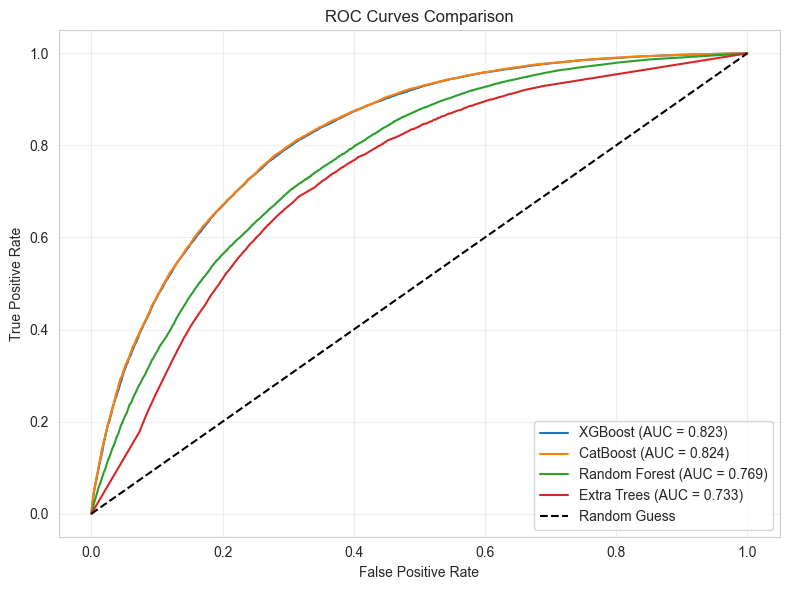

C:\Users\hasit\AppData\Local\Temp\ipykernel_11720\2980999415.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=plot_data, palette='viridis')


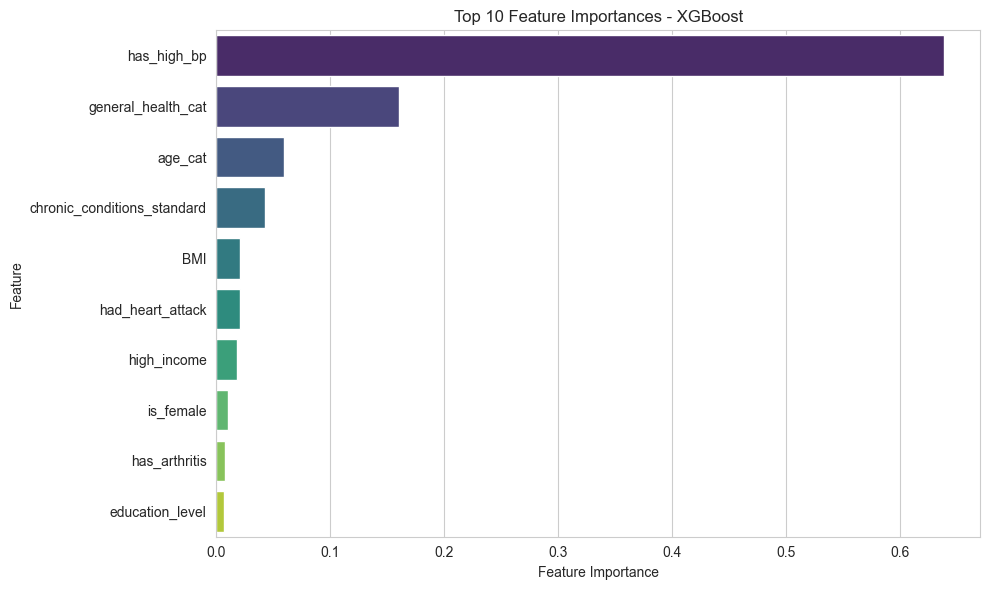

C:\Users\hasit\AppData\Local\Temp\ipykernel_11720\2980999415.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=plot_data, palette='viridis')


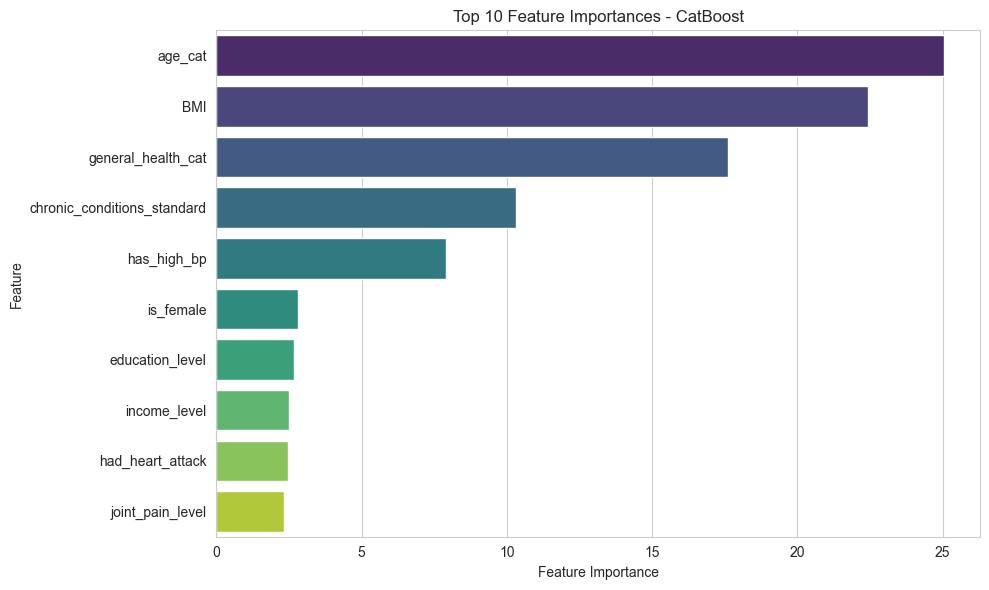

C:\Users\hasit\AppData\Local\Temp\ipykernel_11720\2980999415.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=plot_data, palette='viridis')


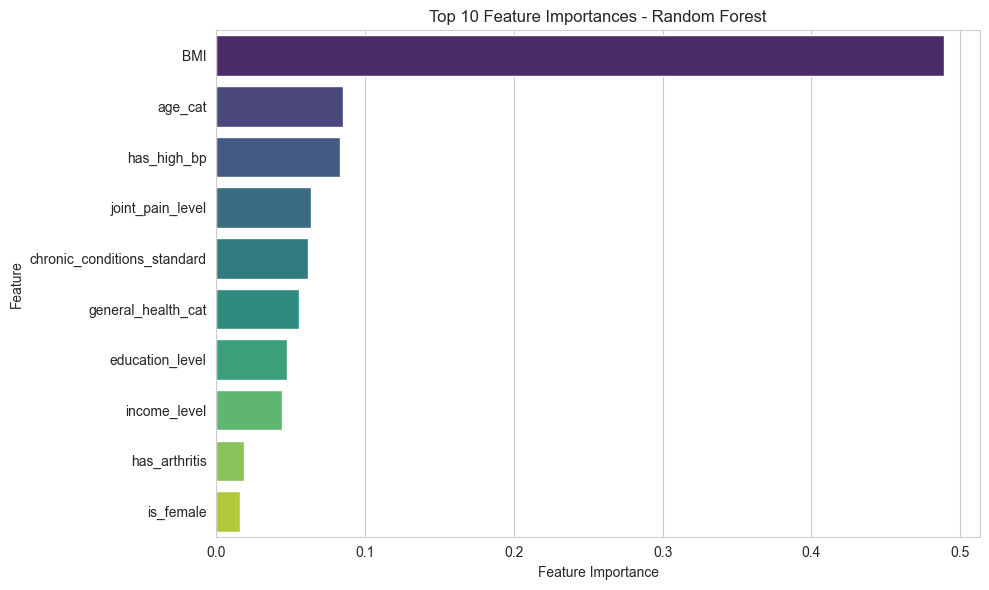

C:\Users\hasit\AppData\Local\Temp\ipykernel_11720\2980999415.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=plot_data, palette='viridis')


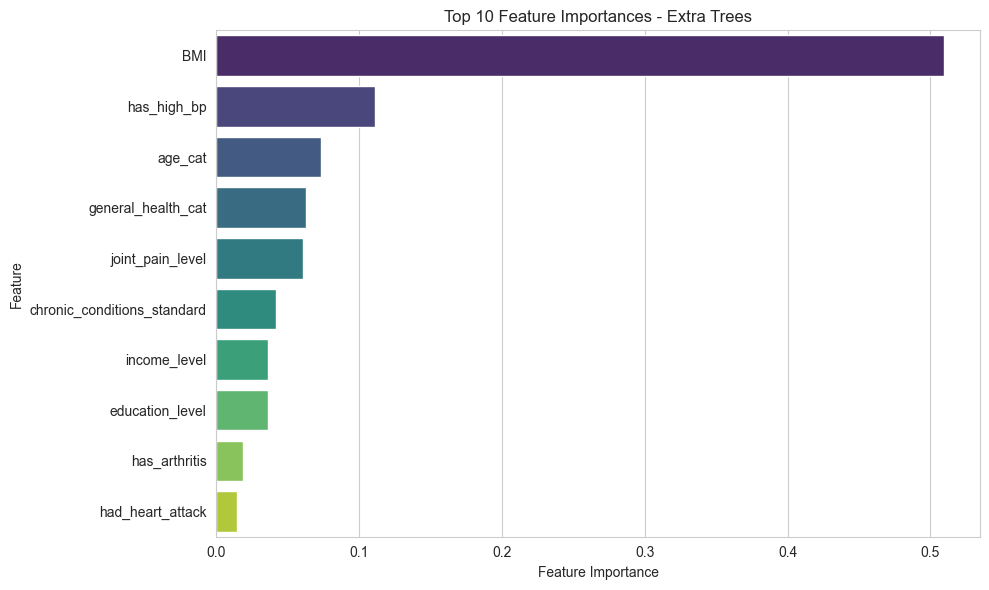


Training and evaluation completed successfully.


In [4]:

# Define paths
data_path = os.path.join("..", "data", "train-test")
models_path = os.path.join("..", "models")

# Create directories if they don't exist
os.makedirs(data_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

# Load data
print("Loading preprocessed data...")
train_df = pd.read_csv(os.path.join(data_path, "train_set.csv"))
test_df = pd.read_csv(os.path.join(data_path, "test_set.csv"))

target = 'has_diabetes'
features = [col for col in train_df.columns if col != target]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Target distribution (train): {y_train.value_counts(normalize=True).map(lambda x: f'{x:.2%}')}")
print(f"Target distribution (test): {y_test.value_counts(normalize=True).map(lambda x: f'{x:.2%}')}")

# Compute scale_pos_weight for XGBoost (handles imbalance)
# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define base models with class imbalance handling
base_models = {
    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_estimators=100,
        tree_method='hist',
        # scale_pos_weight=scale_pos_weight  
    ),
    'CatBoost': CatBoostClassifier(
        iterations=100,
        random_state=42,
        verbose=0,
        thread_count=16,
        # auto_class_weights='Balanced'  
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=16,
        # class_weight='balanced'
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=16,
        # class_weight='balanced'
    )
}



# Storage containers
results = []
feature_importances = {}
roc_curves = {}

# Train and evaluate models
for name, model in base_models.items():
    print(f"\n{'='*60}")
    print(f"TRAINING: {name}")
    print(f"{'='*60}")

    # Train model
    model.fit(X_train, y_train)

    # Save model
    model_filename = f"{name.lower().replace(' ', '_')}_model"
    if name == 'XGBoost':
        model.save_model(os.path.join(models_path, f"{model_filename}.json"))
    else:
        joblib.dump(model, os.path.join(models_path, f"{model_filename}.joblib"))
    print(f"Model saved to {os.path.join(models_path, model_filename)}")

    # Predictions
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': auc
    })

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nCONFUSION MATRIX ({name}):\n{cm}")
    print(f"\nCLASSIFICATION REPORT ({name}):\n")
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

    # Accuracy analysis
    total = cm.sum()
    correct = cm[0,0] + cm[1,1]
    false_negatives = cm[1,0]
    false_positives = cm[0,1]

    print(f"\nAccuracy Analysis for {name}:")
    print(f"   - Overall Accuracy: {acc:.2%} ({correct}/{total} correct)")
    print(f"   - False Negatives (Missed Diabetics): {false_negatives} cases")
    print(f"   - False Positives (False Alarms): {false_positives} cases")

    # Feature importance
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    feature_importances[name] = importance_df

    # ROC curve data
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_curves[name] = (fpr, tpr)

    # Plot and save confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Actual No', 'Actual Yes'])
    plt.title(f'Confusion Matrix - {name}\nAccuracy: {acc:.2%}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Save results to JSON
results_df = pd.DataFrame(results)
results_dict = {
    'test_metrics': results_df.to_dict('records'),
    'timestamp': str(datetime.now())
}
with open(os.path.join(models_path, "model_results.json"), 'w') as f:
    json.dump(results_dict, f, indent=4, default=str)
print(f"\nResults saved to {os.path.join(models_path, 'model_results.json')}")

# Plot and save ROC curves
plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_curves.items():
    auc = results_df[results_df["Model"] == name]["ROC AUC"].iloc[0]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot and save feature importances (Top 10)
sns.set_style("whitegrid")
for name, fi_df in feature_importances.items():
    plt.figure(figsize=(10, 6))
    plot_data = fi_df.head(10)
    sns.barplot(x='Importance', y='Feature', data=plot_data, palette='viridis')
    plt.xlabel('Feature Importance')
    plt.title(f'Top 10 Feature Importances - {name}')
    plt.tight_layout()
    plt.show()

print("\nTraining and evaluation completed successfully.")